# 01 — Data Preparation

## SIADS 696 Milestone II

This notebook prepares the common modeling dataset used by the supervised
and unsupervised learning components of the project.

### Data Source

The raw data were obtained from the U.S. Department of Education
College Scorecard bulk data download.

- Source: College Scorecard — Download the Data
- Download option: All Data Files
- College Scorecard page reports the data were last updated June 10, 2026
- Extracted raw-data directory: `College_Scorecard_Raw_Data_06032026`
- Data include:
  - Institution-level files from 1996-97 through 2025-26
  - Field-of-study files
  - OPEID–UNITID crosswalk files

The raw downloaded files are preserved without modification in `data/raw/`.

### Notebook Goals

The preparation workflow will:

1. Identify and document the required College Scorecard files.
2. Standardize institution identifiers and aggregate institutions to OPEID6.
3. Construct the debt-burden target variable.
4. Clean missing and suppressed values.
5. Identify and remove variables that would introduce outcome leakage.
6. Construct allowable pre-outcome predictors.
7. Perform initial exploratory data analysis.
8. Establish the held-out train/test split.

Learned preprocessing operations such as scaling, imputation parameters,
encoding, and dimensionality reduction will be fit later using training data
only.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Project directories
PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "College_Scorecard_Raw_Data_06032026"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Raw data directory:", RAW_DIR.resolve())
print("Raw directory exists:", RAW_DIR.exists())

Raw data directory: C:\C\Users\froze\Documents\Homework\University of Michigan - Ann Arbor\SIADS 696 - Milestone II Project\data\raw\College_Scorecard_Raw_Data_06032026
Raw directory exists: True


## 1. Raw Data Inventory

Before selecting or transforming the data, we first inventory the College
Scorecard CSV files included in the downloaded bulk release. This helps
document the available data and identify the specific files required for
the analysis.

In [2]:
csv_files = sorted(RAW_DIR.glob("*.csv.gz"))

file_inventory = pd.DataFrame({
    "filename": [f.name for f in csv_files],
    "size_mb": [round(f.stat().st_size / (1024 ** 2), 2) for f in csv_files]
})

print(f"Number of CSV files: {len(file_inventory)}")
file_inventory

Number of CSV files: 40


,filename,size_mb
0,FieldOfStudyData1415_1516_PP.csv,131.09
1,FieldOfStudyData1516_1617_PP.csv,133.98
2,FieldOfStudyData1617_1718_PP.csv,137.50
3,FieldOfStudyData1718_1819_PP.csv,142.85
4,FieldOfStudyData1819_1920_PP.csv,145.41
5,FieldOfStudyData1920_2021_PP.csv,138.57
6,FieldOfStudyData2021_2122_PP.csv,123.01
7,FieldOfStudyData2122_2223_PP.csv,139.27
8,MERGED1996_97_PP.csv,65.90
9,MERGED1997_98_PP.csv,67.74


## 2. Inspect Relevant File Schemas

The bulk download contains multiple types of College Scorecard data at
different levels of observation and across different time periods.

Before selecting variables or merging data, we inspect representative files
from the main data sources needed for the project:

1. Most recent institution-level data
2. Annual institution-level data
3. Most recent field-of-study data

Only a small number of rows are loaded during this step so that the file
schemas can be examined without loading the full datasets into memory.

In [3]:
files_to_inspect = [
    "Most-Recent-Cohorts-Institution.csv.gz",
    "MERGED2023_24_PP.csv.gz",
    "Most-Recent-Cohorts-Field-of-Study.csv.gz"
]

for filename in files_to_inspect:
    path = RAW_DIR / filename
    
    df_sample = pd.read_csv(path, nrows=5, low_memory=False)

    print("=" * 80)
    print(f"File: {filename}")
    print(f"Sample rows loaded: {len(df_sample)}")
    print(f"Number of columns: {len(df_sample.columns)}")
    print("\nColumns:")
    print(df_sample.columns.tolist())
    print()

File: Most-Recent-Cohorts-Institution.csv
Sample rows loaded: 5
Number of columns: 3308

Columns:
['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'ACCREDAGENCY', 'INSTURL', 'NPCURL', 'SCH_DEG', 'HCM2', 'MAIN', 'NUMBRANCH', 'PREDDEG', 'HIGHDEG', 'CONTROL', 'ST_FIPS', 'REGION', 'LOCALE', 'LOCALE2', 'LATITUDE', 'LONGITUDE', 'CCBASIC', 'CCUGPROF', 'CCSIZSET', 'HBCU', 'PBI', 'ANNHI', 'TRIBAL', 'AANAPII', 'HSI', 'NANTI', 'MENONLY', 'WOMENONLY', 'RELAFFIL', 'ADM_RATE', 'ADM_RATE_ALL', 'SATVR25', 'SATVR75', 'SATMT25', 'SATMT75', 'SATWR25', 'SATWR75', 'SATVRMID', 'SATMTMID', 'SATWRMID', 'ACTCM25', 'ACTCM75', 'ACTEN25', 'ACTEN75', 'ACTMT25', 'ACTMT75', 'ACTWR25', 'ACTWR75', 'ACTCMMID', 'ACTENMID', 'ACTMTMID', 'ACTWRMID', 'SAT_AVG', 'SAT_AVG_ALL', 'PCIP01', 'PCIP03', 'PCIP04', 'PCIP05', 'PCIP09', 'PCIP10', 'PCIP11', 'PCIP12', 'PCIP13', 'PCIP14', 'PCIP15', 'PCIP16', 'PCIP19', 'PCIP22', 'PCIP23', 'PCIP24', 'PCIP25', 'PCIP26', 'PCIP27', 'PCIP29', 'PCIP30', 'PCIP31', 'PCIP38', 'PCIP3

## Identify Candidate Outcome and Leakage Variables

The institution-level College Scorecard files contain more than 3,000 variables. Rather than manually reviewing every column, we first search the schema for variables related to the proposed debt-burden outcome and potential sources of target leakage.

The proposed outcome requires measures of student debt and post-entry earnings. Variables related to debt, earnings, repayment, default, and completion are also reviewed as potential leakage variables before constructing the predictor set.

In [4]:
# Load only the column names from the most recent institution-level file
institution_path = RAW_DIR / "Most-Recent-Cohorts-Institution.csv.gz"
institution_columns = pd.read_csv(
    institution_path,
    nrows=0,
    low_memory=False
).columns.tolist()

# Search the schema for terms related to the target and potential leakage
search_terms = [
    "DEBT",
    "EARN",
    "REPAY",
    "DEFAULT",
    "COMP"
]

for term in search_terms:
    matches = [col for col in institution_columns if term in col.upper()]
    
    print("=" * 80)
    print(f"{term}: {len(matches)} matching columns")
    print(matches)
    print()

DEBT: 87 matching columns
['DEBT_MDN', 'GRAD_DEBT_MDN', 'WDRAW_DEBT_MDN', 'LO_INC_DEBT_MDN', 'MD_INC_DEBT_MDN', 'HI_INC_DEBT_MDN', 'DEP_DEBT_MDN', 'IND_DEBT_MDN', 'PELL_DEBT_MDN', 'NOPELL_DEBT_MDN', 'FEMALE_DEBT_MDN', 'MALE_DEBT_MDN', 'FIRSTGEN_DEBT_MDN', 'NOTFIRSTGEN_DEBT_MDN', 'DEBT_N', 'GRAD_DEBT_N', 'WDRAW_DEBT_N', 'LO_INC_DEBT_N', 'MD_INC_DEBT_N', 'HI_INC_DEBT_N', 'DEP_DEBT_N', 'IND_DEBT_N', 'PELL_DEBT_N', 'NOPELL_DEBT_N', 'FEMALE_DEBT_N', 'MALE_DEBT_N', 'FIRSTGEN_DEBT_N', 'NOTFIRSTGEN_DEBT_N', 'GRAD_DEBT_MDN10YR', 'CUML_DEBT_N', 'CUML_DEBT_P90', 'CUML_DEBT_P75', 'CUML_DEBT_P25', 'CUML_DEBT_P10', 'DEBT_MDN_SUPP', 'GRAD_DEBT_MDN_SUPP', 'GRAD_DEBT_MDN10YR_SUPP', 'PLUS_DEBT_INST_N', 'PLUS_DEBT_INST_MD', 'PLUS_DEBT_ALL_N', 'PLUS_DEBT_ALL_MD', 'PLUS_DEBT_INST_COMP_N', 'PLUS_DEBT_INST_COMP_MD', 'PLUS_DEBT_INST_COMP_MDPAY10', 'PLUS_DEBT_INST_COMP_MD_SUPP', 'PLUS_DEBT_INST_COMP_MDPAY10_SUPP', 'PLUS_DEBT_ALL_COMP_N', 'PLUS_DEBT_ALL_COMP_MD', 'PLUS_DEBT_ALL_COMP_MDPAY10', 'PLUS_DEBT_ALL_COM

### Candidate Target Variables

The initial schema search identified candidate variables corresponding to the
two components of the proposed debt-burden outcome. Before constructing the
target, we examine these variables and their availability in the institution-
level data.

The candidate variables are:

- `GRAD_DEBT_MDN`: candidate measure of median debt among completers
- `MD_EARN_WNE_P10`: candidate measure of median earnings 10 years after entry

Their definitions and cohort timing must be verified before they are used to
construct the final outcome.

In [5]:
target_candidates = [
    "UNITID",
    "OPEID",
    "OPEID6",
    "INSTNM",
    "GRAD_DEBT_MDN",
    "MD_EARN_WNE_P10"
]

target_sample = pd.read_csv(
    institution_path,
    usecols=target_candidates,
    nrows=20,
    low_memory=False
)

target_sample

,UNITID,OPEID,OPEID6,INSTNM,GRAD_DEBT_MDN,MD_EARN_WNE_P10
0,100654,100200,1002,Alabama A & M University,31000,40628.0
1,100663,105200,1052,University of Alabama at Birmingham,22300,54501.0
2,100690,2503400,25034,Amridge University,32189,37621.0
3,100706,105500,1055,University of Alabama in Huntsville,20705,61767.0
4,100724,100500,1005,Alabama State University,31000,34502.0
5,100751,105100,1051,The University of Alabama,22750,59221.0
6,100760,100700,1007,Central Alabama Community College,9766,33506.0
7,100812,100800,1008,Athens State University,18051,50273.0
8,100830,831000,8310,Auburn University at Montgomery,25000,44391.0
9,100858,100900,1009,Auburn University,21000,65337.0


## 3. Verify Target Variable Definitions

Before constructing the debt-burden outcome, the candidate target variables
are verified against the metadata distributed with the College Scorecard
download. This ensures that the selected variables represent the intended
measures and time horizons rather than relying only on abbreviated column
names.

In [6]:
metadata_path = RAW_DIR / "data.yaml"

print("Metadata file exists:", metadata_path.exists())
print("Metadata path:", metadata_path.resolve())

# Read the College Scorecard metadata into memory so it can be
# searched throughout the target-definition section.
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata_text = f.read()

# Display the beginning of the metadata file for an initial inspection.
print("\n".join(metadata_text.splitlines()[:40]))

Metadata file exists: True
Metadata path: C:\C\Users\froze\Documents\Homework\University of Michigan - Ann Arbor\SIADS 696 - Milestone II Project\data\raw\College_Scorecard_Raw_Data_06032026\data.yaml
---
version: 2026-05-26-16:42-0700
api: schools
index: school-data
unique:
- id
options:
  columns: all
  search: dictionary_only
null_value:
- 'NULL'
- PrivacySuppressed
- NA
- PS
examples:
- name: College Scorecard Search results
  description: the default scorecard universe
  params: "/v1/schools?page=0&sort=latest.earnings.4_yrs_after_completion.median:desc&school.operating=1&latest.student.size_category=1,2,3&school.degrees_awarded.predominant__range=1..3&fields=id,school.name,school.city,school.state,latest.student.size_category,school.branches,school.locale,school.ownership,school.degrees_awarded.predominant,latest.academics.program_reporter.programs_offered,latest.cost.avg_net_price.overall,latest.completion.consumer_rate,latest.earnings.4_yrs_after_completion.median,latest.earnin

In [7]:
# Print only the lines immediately surrounding each target variable
metadata_lines = metadata_text.splitlines()

target_variables = [
    "GRAD_DEBT_MDN",
    "MD_EARN_WNE_P10"
]

for variable in target_variables:
    print("=" * 80)
    print(f"Variable: {variable}")

    matching_indices = [
        i for i, line in enumerate(metadata_lines)
        if f"source: {variable}" in line
    ]

    if not matching_indices:
        print("Variable not found in data.yaml")
    else:
        for i in matching_indices:
            start = max(0, i - 3)
            end = min(len(metadata_lines), i + 4)

            for line in metadata_lines[start:end]:
                print(line)

    print()

Variable: GRAD_DEBT_MDN
    type: float
    description: The median original amount of the loan principal upon entering repayment
  aid.median_debt.completers.overall:
    source: GRAD_DEBT_MDN
    type: float
    description: The median debt for students who have completed
  aid.median_debt.noncompleters:
    type: integer
    description: The number of students in the median debt not-first-generation students cohort
  aid.median_debt.completers.monthly_payments:
    source: GRAD_DEBT_MDN10YR
    type: float
    description: Median loan debt of completers in monthly payments (10-year amortization plan)
  aid.cumulative_debt.number:
    type: float
    description: Median debt, suppressed for n=30
  aid.median_debt_suppressed.completers.overall:
    source: GRAD_DEBT_MDN_SUPP
    type: float
    description: Median debt of completers, suppressed for n=30
  aid.median_debt_suppressed.completers.monthly_payments:
    type: float
    description: Median debt of completers, suppressed for 

In [8]:
earnings_variable = "MD_EARN_WNE_P10"

for i, line in enumerate(metadata_lines):
    if f"source: {earnings_variable}" in line:
        for nearby_line in metadata_lines[max(0, i - 2):i + 3]:
            print(nearby_line)
        break

    description: Mean earnings of students working and not enrolled 10 years after entry
  earnings.10_yrs_after_entry.median:
    source: MD_EARN_WNE_P10
    type: integer
    description: Median earnings of students working and not enrolled 10 years after entry


## 4. Construct the Debt-Burden Outcome

The supervised learning outcome is defined as the natural logarithm of the ratio between median debt among completers and median earnings 10 years after entry:

$$
\text{Debt Burden} =
\log\left(
\frac{\text{Median Completer Debt}}
{\text{Median Earnings 10 Years After Entry}}
\right)
$$

The College Scorecard metadata identifies:

- `GRAD_DEBT_MDN` as the median debt for students who have completed.
- `MD_EARN_WNE_P10` as the median earnings of students working and not enrolled 10 years after entry.

College Scorecard suppressed values such as `PS`, `PrivacySuppressed`, `NA`, and `NULL` are treated as missing values before the outcome is calculated.

In [9]:
target_columns = [
    "UNITID",
    "OPEID",
    "OPEID6",
    "INSTNM",
    "GRAD_DEBT_MDN",
    "MD_EARN_WNE_P10"
]

target_df = pd.read_csv(
    institution_path,
    usecols=target_columns,
    na_values=["PS", "PrivacySuppressed", "NA", "NULL"],
    low_memory=False
)

print("Rows loaded:", len(target_df))
print("\nData types:")
print(target_df.dtypes)

print("\nMissing values:")
print(target_df[["GRAD_DEBT_MDN", "MD_EARN_WNE_P10"]].isna().sum())

Rows loaded: 6273

Data types:
UNITID               int64
OPEID              float64
OPEID6             float64
INSTNM                 str
GRAD_DEBT_MDN      float64
MD_EARN_WNE_P10    float64
dtype: object

Missing values:
GRAD_DEBT_MDN      1496
MD_EARN_WNE_P10    1146
dtype: int64


### Target Validity Checks

Before calculating the debt-burden outcome, both target components are checked
for missing, zero, and negative values. The logarithmic outcome requires both
median debt and median earnings to be present and strictly greater than zero.

In [10]:
debt = target_df["GRAD_DEBT_MDN"]
earnings = target_df["MD_EARN_WNE_P10"]

target_checks = pd.Series({
    "Total rows": len(target_df),
    "Missing debt": debt.isna().sum(),
    "Missing earnings": earnings.isna().sum(),
    "Missing either component": (debt.isna() | earnings.isna()).sum(),
    "Missing both components": (debt.isna() & earnings.isna()).sum(),
    "Debt <= 0": (debt <= 0).sum(),
    "Earnings <= 0": (earnings <= 0).sum(),
    "Valid target rows": (
        debt.notna()
        & earnings.notna()
        & (debt > 0)
        & (earnings > 0)
    ).sum()
})

target_checks

Total rows                  6273
Missing debt                1496
Missing earnings            1146
Missing either component    1808
Missing both components      834
Debt <= 0                      0
Earnings <= 0                  0
Valid target rows           4465
dtype: int64

### Construct the Final Outcome

Rows without both target components are excluded from the target dataset.
Because all observed debt and earnings values are strictly positive, the
debt-burden outcome can be calculated as the natural logarithm of the ratio
between median completer debt and median earnings 10 years after entry.

In [11]:
# Keep only rows with valid values for both target components
target_valid = target_df.loc[
    target_df["GRAD_DEBT_MDN"].notna()
    & target_df["MD_EARN_WNE_P10"].notna()
    & (target_df["GRAD_DEBT_MDN"] > 0)
    & (target_df["MD_EARN_WNE_P10"] > 0)
].copy()

# Construct the debt-burden outcome
target_valid["debt_burden"] = np.log(
    target_valid["GRAD_DEBT_MDN"]
    / target_valid["MD_EARN_WNE_P10"]
)

print("Valid target rows:", len(target_valid))

target_valid[
    [
        "UNITID",
        "OPEID6",
        "INSTNM",
        "GRAD_DEBT_MDN",
        "MD_EARN_WNE_P10",
        "debt_burden"
    ]
].head(10)

Valid target rows: 4465


,UNITID,OPEID6,INSTNM,GRAD_DEBT_MDN,MD_EARN_WNE_P10,debt_burden
0,100654,1002.0,Alabama A & M University,31000.0,40628.0,-0.270470
1,100663,1052.0,University of Alabama at Birmingham,22300.0,54501.0,-0.893632
2,100690,25034.0,Amridge University,32189.0,37621.0,-0.155938
3,100706,1055.0,University of Alabama in Huntsville,20705.0,61767.0,-1.092994
4,100724,1005.0,Alabama State University,31000.0,34502.0,-0.107030
5,100751,1051.0,The University of Alabama,22750.0,59221.0,-0.956711
6,100760,1007.0,Central Alabama Community College,9766.0,33506.0,-1.232818
7,100812,1008.0,Athens State University,18051.0,50273.0,-1.024267
8,100830,8310.0,Auburn University at Montgomery,25000.0,44391.0,-0.574161
9,100858,1009.0,Auburn University,21000.0,65337.0,-1.135036


### Inspect the Outcome Distribution

The distribution of the constructed debt-burden outcome is examined before
merging it with predictor data. Summary statistics and a histogram are used
to identify the overall range, skew, and potential extreme values.

count    4465.000000
mean       -1.082563
std         0.419720
min        -2.661395
25%        -1.357239
50%        -1.088167
75%        -0.793897
max         0.489740
Name: debt_burden, dtype: float64


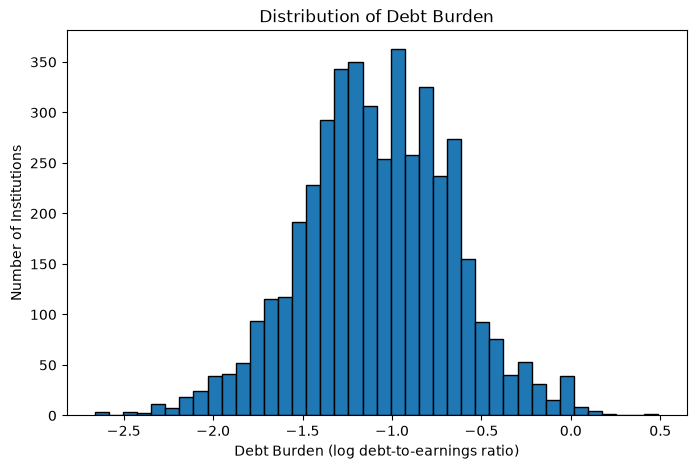

In [12]:
# Summary statistics
print(target_valid["debt_burden"].describe())

# Distribution of the target
plt.figure(figsize=(8, 5))
plt.hist(target_valid["debt_burden"], bins=40, edgecolor="black")
plt.xlabel("Debt Burden (log debt-to-earnings ratio)")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Debt Burden")
plt.show()

## 5. Establish the OPEID6 Unit of Analysis

College Scorecard institution-level records are identified by `UNITID`, while
the project uses `OPEID6` as the common institutional identifier for combining
data sources. Before aggregation, we examine whether multiple institution
records share the same OPEID6 and therefore require consolidation.

In [13]:
# Check OPEID6 availability and uniqueness among valid target rows
print("Valid target rows:", len(target_valid))
print("Missing OPEID6:", target_valid["OPEID6"].isna().sum())
print("Unique OPEID6 values:", target_valid["OPEID6"].nunique())

# Count how many UNITIDs are associated with each OPEID6
opeid6_counts = (
    target_valid.groupby("OPEID6")["UNITID"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nOPEID6 values with multiple UNITIDs:",
      (opeid6_counts > 1).sum())

print("Maximum UNITIDs associated with one OPEID6:",
      opeid6_counts.max())

print("\nLargest OPEID6 groups:")
display(opeid6_counts.head(15))

Valid target rows: 4465
Missing OPEID6: 0
Unique OPEID6 values: 3310

OPEID6 values with multiple UNITIDs: 372
Maximum UNITIDs associated with one OPEID6: 31

Largest OPEID6 groups:


OPEID6
22606.0    31
1459.0     27
30837.0    23
3329.0     22
31150.0    20
9917.0     20
41341.0    19
8694.0     19
23068.0    18
21519.0    17
1081.0     17
2678.0     17
10198.0    17
21207.0    17
9748.0     16
Name: UNITID, dtype: int64

### Inspect Multi-UNITID OPEID6 Groups

Because multiple `UNITID` records can share the same `OPEID6`, duplicated
OPEID6 groups are inspected before aggregation. This determines whether the
target components are repeated across branch records or vary within an OPEID6
group and therefore require an explicit aggregation rule.

In [14]:
# Select several of the largest OPEID6 groups for inspection
largest_opeid6 = opeid6_counts.head(5).index

duplicate_sample = (
    target_valid.loc[
        target_valid["OPEID6"].isin(largest_opeid6),
        [
            "OPEID6",
            "UNITID",
            "INSTNM",
            "GRAD_DEBT_MDN",
            "MD_EARN_WNE_P10",
            "debt_burden"
        ]
    ]
    .sort_values(["OPEID6", "UNITID"])
)

duplicate_sample

,OPEID6,UNITID,INSTNM,GRAD_DEBT_MDN,MD_EARN_WNE_P10,debt_burden
569,1459.0,131803,Strayer University-District of Columbia,40621.0,40092.0,0.013108
3246,1459.0,233684,Strayer University-Virginia,40621.0,40092.0,0.013108
3988,1459.0,430184,Strayer University-Maryland,40621.0,40092.0,0.013108
4210,1459.0,443766,Strayer University-Tennessee,40621.0,40092.0,0.013108
4211,1459.0,443784,Strayer University-Pennsylvania,40621.0,40092.0,0.013108
...,...,...,...,...,...,...
5680,31150.0,499398,Arizona College of Nursing-Cincinnati,9500.0,34657.0,-1.294208
5681,31150.0,499404,Arizona College of Nursing-Cleveland,9500.0,34657.0,-1.294208
5718,31150.0,500290,Arizona College of Nursing - Chesapeake,9500.0,34657.0,-1.294208
5719,31150.0,500306,Arizona College of Nursing - Hartford,9500.0,34657.0,-1.294208


### Verify Target Consistency Within OPEID6

The inspected multi-branch institutions appear to report identical outcome
values across `UNITID` records sharing the same `OPEID6`. We test this pattern
across the full valid-target dataset before collapsing the outcome to one row
per OPEID6.

In [15]:
# Count the number of distinct target values within each OPEID6
target_consistency = (
    target_valid.groupby("OPEID6")
    .agg(
        n_unitids=("UNITID", "nunique"),
        n_debt_values=("GRAD_DEBT_MDN", "nunique"),
        n_earnings_values=("MD_EARN_WNE_P10", "nunique"),
        n_burden_values=("debt_burden", "nunique")
    )
)

print(
    "OPEID6 groups with multiple debt values:",
    (target_consistency["n_debt_values"] > 1).sum()
)

print(
    "OPEID6 groups with multiple earnings values:",
    (target_consistency["n_earnings_values"] > 1).sum()
)

print(
    "OPEID6 groups with multiple debt-burden values:",
    (target_consistency["n_burden_values"] > 1).sum()
)

OPEID6 groups with multiple debt values: 0
OPEID6 groups with multiple earnings values: 0
OPEID6 groups with multiple debt-burden values: 0


### Collapse the Outcome to OPEID6

All `UNITID` records sharing an `OPEID6` have identical values for median
completer debt, median 10-year earnings, and the constructed debt-burden
outcome. The repeated branch-level outcome records can therefore be collapsed
to one observation per OPEID6 without averaging the target.

In [16]:
# Collapse repeated branch-level outcome records to one row per OPEID6
target_opeid6 = (
    target_valid[
        [
            "OPEID6",
            "GRAD_DEBT_MDN",
            "MD_EARN_WNE_P10",
            "debt_burden"
        ]
    ]
    .drop_duplicates(subset="OPEID6")
    .reset_index(drop=True)
)

print("OPEID6-level target rows:", len(target_opeid6))
print("Unique OPEID6 values:", target_opeid6["OPEID6"].nunique())
print("Duplicate OPEID6 values:", target_opeid6["OPEID6"].duplicated().sum())

target_opeid6.head(10)

OPEID6-level target rows: 3310
Unique OPEID6 values: 3310
Duplicate OPEID6 values: 0


,OPEID6,GRAD_DEBT_MDN,MD_EARN_WNE_P10,debt_burden
0,1002.0,31000.0,40628.0,-0.270470
1,1052.0,22300.0,54501.0,-0.893632
2,25034.0,32189.0,37621.0,-0.155938
3,1055.0,20705.0,61767.0,-1.092994
4,1005.0,31000.0,34502.0,-0.107030
5,1051.0,22750.0,59221.0,-0.956711
6,1007.0,9766.0,33506.0,-1.232818
7,1008.0,18051.0,50273.0,-1.024267
8,8310.0,25000.0,44391.0,-0.574161
9,1009.0,21000.0,65337.0,-1.135036


## 6. Determine Predictor–Outcome Time Alignment

The outcome includes median earnings measured 10 years after student entry.
Predictor variables should represent information available before the outcome
is observed to avoid temporal leakage.

Before selecting historical institution-level files for predictors, the
College Scorecard metadata is examined for information about the cohort and
measurement period associated with the 10-year earnings outcome.

In [17]:
# Locate all metadata lines containing the 10-year median earnings variable
# and print a wider surrounding section to inspect cohort information.
earnings_variable = "MD_EARN_WNE_P10"

for i, line in enumerate(metadata_lines):
    if earnings_variable in line:
        print("=" * 80)
        print(f"Match at metadata line {i}")
        print()

        start = max(0, i - 15)
        end = min(len(metadata_lines), i + 16)

        for nearby_line in metadata_lines[start:end]:
            print(nearby_line)

        print()

Match at metadata line 6672

    type: float
    description: Share of students who submitted FAFSAs to at least five colleges
  earnings.10_yrs_after_entry.not_working_not_enrolled.overall:
    source: COUNT_NWNE_P10
    type: integer
    description: Number of students not working and not enrolled 10 years after entry
  earnings.10_yrs_after_entry.working_not_enrolled.overall:
    source: COUNT_WNE_P10
    type: integer
    description: Number of students working and not enrolled 10 years after entry
  earnings.10_yrs_after_entry.working_not_enrolled.mean_earnings:
    source: MN_EARN_WNE_P10
    type: integer
    description: Mean earnings of students working and not enrolled 10 years after entry
  earnings.10_yrs_after_entry.median:
    source: MD_EARN_WNE_P10
    type: integer
    description: Median earnings of students working and not enrolled 10 years after entry
    index: integer
  earnings.10_yrs_after_entry.working_not_enrolled.earnings_percentile.10:
    source: PCT10_EARN

### Examine Outcome Availability Across Annual Files

The metadata defines `MD_EARN_WNE_P10` as median earnings 10 years after
student entry but does not specify the associated calendar-year cohort in the
variable description. We therefore examine the availability of this outcome
across the annual institution-level College Scorecard files before selecting
the historical predictor period.

In [18]:
merged_files = sorted(RAW_DIR.glob("MERGED*_PP.csv.gz"))

earnings_availability = []

for path in merged_files:
    # Read only the target column to keep this check lightweight
    df = pd.read_csv(
        path,
        usecols=["MD_EARN_WNE_P10"],
        na_values=["PS", "PrivacySuppressed", "NA", "NULL"],
        low_memory=False
    )

    earnings_availability.append({
        "file": path.name,
        "rows": len(df),
        "nonmissing_MD_EARN_WNE_P10": df["MD_EARN_WNE_P10"].notna().sum()
    })

earnings_availability = pd.DataFrame(earnings_availability)

earnings_availability

,file,rows,nonmissing_MD_EARN_WNE_P10
0,MERGED1996_97_PP.csv,7007,0
1,MERGED1997_98_PP.csv,6934,0
2,MERGED1998_99_PP.csv,6702,0
3,MERGED1999_00_PP.csv,6609,0
4,MERGED2000_01_PP.csv,6654,0
5,MERGED2001_02_PP.csv,6725,0
6,MERGED2002_03_PP.csv,6652,0
7,MERGED2003_04_PP.csv,6673,0
8,MERGED2004_05_PP.csv,6747,0
9,MERGED2005_06_PP.csv,6899,0


## 7. Identify Candidate Pre-Outcome Predictors

The supervised models should use institutional characteristics that are
available before the long-run earnings outcome rather than variables that
directly measure later student outcomes.

A historical College Scorecard institution-level file is therefore inspected
for candidate predictors describing institutional characteristics, student
composition, admissions, costs, enrollment, and academic offerings. Outcome
variables related to debt, earnings, repayment, default, and later completion
will be excluded from the predictor matrix.

### Select the Historical Institution-Level Predictor File

The 2014-15 institution-level file is used as the historical predictor source.
This provides an early institutional snapshot for constructing predictors
intended to precede the long-run earnings outcome. The corresponding earliest
available field-of-study data are examined separately below.

In [19]:
predictor_path = RAW_DIR / "MERGED2014_15_PP.csv.gz"

predictor_columns = pd.read_csv(
    predictor_path,
    nrows=0,
    low_memory=False
).columns.tolist()

candidate_predictors = [
    # Institution characteristics
    "UNITID", "OPEID", "OPEID6", "INSTNM",
    "CONTROL", "REGION", "LOCALE", "PREDDEG", "HIGHDEG",
    "MAIN", "NUMBRANCH",

    # Enrollment
    "UGDS",

    # Student composition
    "UGDS_WHITE", "UGDS_BLACK", "UGDS_HISP",
    "UGDS_ASIAN", "UGDS_AIAN", "UGDS_NHPI",
    "UGDS_2MOR", "UGDS_NRA", "UGDS_UNKN",
    "PPTUG_EF",

    # Socioeconomic / aid characteristics
    "PCTPELL", "PCTFLOAN",

    # Admissions
    "ADM_RATE", "SAT_AVG",

    # Cost
    "TUITIONFEE_IN", "TUITIONFEE_OUT",
    "COSTT4_A", "COSTT4_P",
    "NPT4_PUB", "NPT4_PRIV"
]

available_predictors = [
    col for col in candidate_predictors
    if col in predictor_columns
]

missing_predictors = [
    col for col in candidate_predictors
    if col not in predictor_columns
]

print("Candidate variables available:", len(available_predictors))
print(available_predictors)

print("\nCandidate variables not available:")
print(missing_predictors)

Candidate variables available: 32
['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CONTROL', 'REGION', 'LOCALE', 'PREDDEG', 'HIGHDEG', 'MAIN', 'NUMBRANCH', 'UGDS', 'UGDS_WHITE', 'UGDS_BLACK', 'UGDS_HISP', 'UGDS_ASIAN', 'UGDS_AIAN', 'UGDS_NHPI', 'UGDS_2MOR', 'UGDS_NRA', 'UGDS_UNKN', 'PPTUG_EF', 'PCTPELL', 'PCTFLOAN', 'ADM_RATE', 'SAT_AVG', 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'COSTT4_A', 'COSTT4_P', 'NPT4_PUB', 'NPT4_PRIV']

Candidate variables not available:
[]


### Inspect Candidate Predictor Data

After confirming that the proposed predictor variables are available in the
historical institution-level file, we load them for closer inspection.

Before cleaning or aggregating the predictors, we examine their data types,
missingness, and sample values. This helps identify variables that require
numeric conversion or special handling before the predictor dataset is
constructed.

In [20]:
predictor_df = pd.read_csv(
    predictor_path,
    usecols=available_predictors,
    na_values=["PS", "PrivacySuppressed", "NA", "NULL"],
    low_memory=False
)

print("Rows loaded:", len(predictor_df))
print("Columns loaded:", len(predictor_df.columns))

predictor_summary = pd.DataFrame({
    "dtype": predictor_df.dtypes.astype(str),
    "missing": predictor_df.isna().sum(),
    "missing_pct": (
        predictor_df.isna().mean() * 100
    ).round(2),
    "unique_values": predictor_df.nunique(dropna=True)
})

predictor_summary

Rows loaded: 7766
Columns loaded: 32


,dtype,missing,missing_pct,unique_values
UNITID,int64,0,0.00,7766
OPEID,int64,0,0.00,7737
OPEID6,int64,0,0.00,5715
INSTNM,str,0,0.00,7562
MAIN,int64,0,0.00,2
NUMBRANCH,int64,0,0.00,25
PREDDEG,int64,0,0.00,5
HIGHDEG,int64,0,0.00,5
CONTROL,int64,0,0.00,3
REGION,int64,0,0.00,10


### Refine Predictors and Inspect OPEID6 Groups

`LOCALE` is entirely missing in the 2014-15 predictor file and therefore
cannot provide information for the analysis. It is removed from the candidate
predictor set.

The historical predictor data contain multiple `UNITID` records for some
OPEID6 institutions. Because the modeling outcome has already been collapsed
to one row per OPEID6, the predictor data must also be consolidated to the
same unit of analysis. Before choosing an aggregation strategy, we inspect
the number of branch records associated with each OPEID6.

In [21]:
# Remove LOCALE because it contains no observed values in the 2014-15 data
predictor_df = predictor_df.drop(columns=["LOCALE"])

# Count the number of UNITID records associated with each OPEID6
predictor_opeid6_counts = (
    predictor_df.groupby("OPEID6")["UNITID"]
    .nunique()
    .sort_values(ascending=False)
)

# Summarize how often multiple UNITIDs occur within the same OPEID6
print("Predictor rows:", len(predictor_df))
print("Unique OPEID6 values:", predictor_df["OPEID6"].nunique())

print(
    "OPEID6 values with multiple UNITIDs:",
    (predictor_opeid6_counts > 1).sum()
)

print(
    "Maximum UNITIDs associated with one OPEID6:",
    predictor_opeid6_counts.max()
)

# Inspect the largest multi-branch OPEID6 groups
print("\nLargest OPEID6 groups:")
display(predictor_opeid6_counts.head(15))

Predictor rows: 7766
Unique OPEID6 values: 5715
OPEID6 values with multiple UNITIDs: 627
Maximum UNITIDs associated with one OPEID6: 142

Largest OPEID6 groups:


OPEID6
7329     142
10490     85
1459      81
20988     38
30106     33
40513     33
4057      33
21799     29
10727     25
3329      24
8694      23
2678      19
30265     18
13039     17
23328     15
Name: UNITID, dtype: int64

### Inspect Branch Structure Within OPEID6

A substantial number of OPEID6 institutions contain multiple `UNITID`
records, with some systems containing many branch-level observations.

Before aggregating predictors, we examine whether multi-UNITID OPEID6 groups
contain a clearly identified main campus and whether institutional
characteristics differ across their branch records. This helps determine
whether main-campus values or aggregated branch-level values are more
appropriate for different predictor types.

In [22]:
# Identify OPEID6 groups that contain more than one UNITID
multi_opeid6 = predictor_opeid6_counts[
    predictor_opeid6_counts > 1
].index

multi_branch_df = predictor_df[
    predictor_df["OPEID6"].isin(multi_opeid6)
].copy()

# Count the number of MAIN == 1 records within each multi-branch OPEID6
main_counts = (
    multi_branch_df.groupby("OPEID6")["MAIN"]
    .apply(lambda x: (x == 1).sum())
)

print("Multi-UNITID OPEID6 groups:", len(main_counts))
print("Groups with exactly one main campus:", (main_counts == 1).sum())
print("Groups with no main campus:", (main_counts == 0).sum())
print("Groups with multiple main campuses:", (main_counts > 1).sum())

# Inspect several of the largest branch systems and selected characteristics
largest_groups = predictor_opeid6_counts.head(5).index

branch_sample = (
    predictor_df.loc[
        predictor_df["OPEID6"].isin(largest_groups),
        [
            "OPEID6",
            "UNITID",
            "INSTNM",
            "MAIN",
            "CONTROL",
            "REGION",
            "PREDDEG",
            "HIGHDEG",
            "UGDS",
            "PCTPELL",
            "PCTFLOAN"
        ]
    ]
    .sort_values(["OPEID6", "MAIN", "UNITID"], ascending=[True, False, True])
)

display(branch_sample)

Multi-UNITID OPEID6 groups: 627
Groups with exactly one main campus: 624
Groups with no main campus: 2
Groups with multiple main campuses: 1


,OPEID6,UNITID,INSTNM,MAIN,CONTROL,REGION,PREDDEG,HIGHDEG,UGDS,PCTPELL,PCTFLOAN
714,1459,131803,Strayer University-District of Columbia,1,3,2,3,4,774.0,0.4227,0.5617
3988,1459,233684,Strayer University-Virginia,0,3,5,3,4,4448.0,0.2993,0.4036
5155,1459,430184,Strayer University-Maryland,0,3,2,3,4,1950.0,0.3469,0.4894
5588,1459,443766,Strayer University-Tennessee,0,3,5,3,4,1273.0,0.5551,0.6414
5589,1459,443784,Strayer University-Pennsylvania,0,3,2,3,4,1537.0,0.4873,0.6031
...,...,...,...,...,...,...,...,...,...,...,...
6916,30106,476337,Golf Academy of America-Dallas,0,3,6,2,2,80.0,0.4710,0.5072
7014,30106,480107,Virginia College-Florence,0,3,5,1,2,414.0,0.9157,0.8004
7042,30106,480815,Virginia College-Greensboro,0,3,5,1,1,513.0,0.9267,0.8578
7203,30106,483319,Virginia College-Lubbock,0,3,6,2,0,167.0,NaN,NaN


### Inspect Exceptions to the Main-Campus Structure

Nearly all multi-UNITID OPEID6 groups contain exactly one record identified as
the main campus. A small number of groups either contain no main-campus record
or contain more than one.

These exceptions are inspected before defining the OPEID6 aggregation rules so
that the predictor construction does not depend on an assumption that fails for
these institutions.

In [23]:
# Identify multi-branch OPEID6 groups that do not have exactly one main campus
main_exceptions = main_counts[main_counts != 1]

print("OPEID6 groups without exactly one main campus:")
display(main_exceptions)

# Retrieve all UNITID records belonging to these exceptional groups
exception_details = (
    predictor_df.loc[
        predictor_df["OPEID6"].isin(main_exceptions.index),
        [
            "OPEID6",
            "UNITID",
            "INSTNM",
            "MAIN",
            "CONTROL",
            "REGION",
            "PREDDEG",
            "HIGHDEG",
            "UGDS"
        ]
    ]
    .sort_values(["OPEID6", "MAIN", "UNITID"], ascending=[True, False, True])
)

print("\nRecords belonging to these groups:")
display(exception_details)

OPEID6 groups without exactly one main campus:


OPEID6
9917     2
20527    0
22419    0
Name: MAIN, dtype: int64


Records belonging to these groups:


,OPEID6,UNITID,INSTNM,MAIN,CONTROL,REGION,PREDDEG,HIGHDEG,UGDS
1202,9917,150987,Ivy Tech Community College,1,1,3,1,2,77657.0
7484,9917,15098714,Ivy Tech Community College-Indianapolis,1,1,3,0,0,NaN
7471,9917,15098701,Ivy Tech Community College-South Bend/Elkhart,0,1,3,0,0,NaN
7472,9917,15098702,Ivy Tech Community College-Columbus,0,1,3,0,0,NaN
7473,9917,15098703,Ivy Tech Community College-Muncie,0,1,3,0,0,NaN
7474,9917,15098704,Ivy Tech Community College-Kokomo,0,1,3,0,0,NaN
7475,9917,15098705,Ivy Tech Community College-Lafayette,0,1,3,0,0,NaN
7476,9917,15098706,Ivy Tech Community College-Fort Wayne,0,1,3,0,0,NaN
7477,9917,15098707,Ivy Tech Community College-Sellersburg,0,1,3,0,0,NaN
7478,9917,15098708,Ivy Tech Community College-Evansville,0,1,3,0,0,NaN


### Aggregate Institution-Level Predictors to OPEID6

The target is defined at the OPEID6 level, while the historical predictor
data may contain multiple UNITID records for the same OPEID6. Predictor
variables are therefore aggregated to create one observation per OPEID6.

Undergraduate enrollment (`UGDS`) is summed across branch records. Student
composition, aid, admissions, and cost measures are aggregated using
undergraduate-enrollment-weighted averages so that larger branches contribute
more strongly to the OPEID6-level value. Institutional descriptors are taken
from the branch with the largest observed undergraduate enrollment, providing
a consistent rule even for OPEID6 groups without exactly one designated main
campus.

Missing values are retained when no usable observations are available rather
than being imputed during this stage.

In [24]:
# Variables that describe institutional characteristics
descriptor_cols = [
    "CONTROL",
    "REGION",
    "PREDDEG",
    "HIGHDEG",
    "NUMBRANCH"
]

# Variables that should be averaged across branches using undergraduate
# enrollment as the weight
weighted_cols = [
    "UGDS_WHITE",
    "UGDS_BLACK",
    "UGDS_HISP",
    "UGDS_ASIAN",
    "UGDS_AIAN",
    "UGDS_NHPI",
    "UGDS_2MOR",
    "UGDS_NRA",
    "UGDS_UNKN",
    "PPTUG_EF",
    "PCTPELL",
    "PCTFLOAN",
    "ADM_RATE",
    "SAT_AVG",
    "TUITIONFEE_IN",
    "TUITIONFEE_OUT",
    "COSTT4_A",
    "COSTT4_P",
    "NPT4_PUB",
    "NPT4_PRIV"
]


def weighted_mean(group, column):
    """
    Calculate an undergraduate-enrollment-weighted mean for one variable.

    Only rows with both a non-missing variable value and a positive UGDS
    value contribute to the weighted average.
    """
    valid = (
        group[column].notna()
        & group["UGDS"].notna()
        & (group["UGDS"] > 0)
    )

    if valid.sum() == 0:
        return np.nan

    return np.average(
        group.loc[valid, column],
        weights=group.loc[valid, "UGDS"]
    )


opeid6_rows = []

for opeid6, group in predictor_df.groupby("OPEID6"):

    # Use the largest branch by undergraduate enrollment as the
    # representative record for institutional descriptors.
    if group["UGDS"].notna().any():
        representative_idx = group["UGDS"].fillna(-1).idxmax()
    else:
        # This fallback is only used when every branch is missing UGDS.
        representative_idx = group.index[0]

    representative = group.loc[representative_idx]

    row = {
        "OPEID6": opeid6,

        # Sum enrollment across branches. min_count=1 keeps the result
        # missing when every branch has missing enrollment.
        "UGDS": group["UGDS"].sum(min_count=1)
    }

    # Copy institutional descriptors from the representative branch
    for column in descriptor_cols:
        row[column] = representative[column]

    # Calculate enrollment-weighted averages for branch-level measures
    for column in weighted_cols:
        row[column] = weighted_mean(group, column)

    opeid6_rows.append(row)


predictors_opeid6 = pd.DataFrame(opeid6_rows)

print("Original UNITID-level rows:", len(predictor_df))
print("OPEID6-level predictor rows:", len(predictors_opeid6))
print("Unique OPEID6 values:", predictors_opeid6["OPEID6"].nunique())
print(
    "Duplicate OPEID6 values:",
    predictors_opeid6["OPEID6"].duplicated().sum()
)

predictors_opeid6.head(10)

Original UNITID-level rows: 7766
OPEID6-level predictor rows: 5715
Unique OPEID6 values: 5715
Duplicate OPEID6 values: 0


,OPEID6,UGDS,CONTROL,REGION,PREDDEG,HIGHDEG,NUMBRANCH,UGDS_WHITE,UGDS_BLACK,UGDS_HISP,...,PCTPELL,PCTFLOAN,ADM_RATE,SAT_AVG,TUITIONFEE_IN,TUITIONFEE_OUT,COSTT4_A,COSTT4_P,NPT4_PUB,NPT4_PRIV
0,1002,4206.0,1,5,3,4,1,0.0333,0.9353,0.0055,...,0.7356,0.8284,0.5256,827.0,9096.0,16596.0,21475.0,NaN,15229.0,NaN
1,1003,2367.0,2,5,3,4,1,0.3874,0.5137,0.0258,...,0.5812,0.7253,NaN,NaN,18750.0,18750.0,30116.0,NaN,NaN,20240.0
2,1004,2644.0,1,5,3,4,1,0.7266,0.1384,0.0310,...,0.3972,0.5856,0.7430,1070.0,10660.0,21220.0,22440.0,NaN,16877.0,NaN
3,1005,4811.0,1,5,3,4,1,0.0158,0.9208,0.0121,...,0.7347,0.7554,0.5326,851.0,8720.0,15656.0,18184.0,NaN,11110.0,NaN
4,1007,1592.0,1,5,2,2,1,0.7255,0.2613,0.0044,...,0.5892,0.3977,NaN,NaN,3491.0,6576.0,12054.0,NaN,6922.0,NaN
5,1008,2991.0,1,5,3,3,1,0.7823,0.1200,0.0191,...,0.4088,0.6296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1009,20514.0,1,5,3,4,1,0.8507,0.0704,0.0248,...,0.1610,0.3494,0.8347,1215.0,10200.0,27384.0,25282.0,NaN,18644.0,NaN
7,1012,1180.0,2,5,3,3,1,0.7983,0.1102,0.0195,...,0.1920,0.4809,0.5339,1181.0,31708.0,31708.0,45162.0,NaN,NaN,18728.0
8,1013,9380.0,1,5,2,2,1,0.6528,0.1940,0.0435,...,0.3933,0.3024,NaN,NaN,4260.0,7650.0,10052.0,NaN,5686.0,NaN
9,1015,1729.0,1,5,2,2,1,0.6408,0.2435,0.0509,...,0.4895,0.2263,NaN,NaN,3976.0,7140.0,8676.0,NaN,3762.0,NaN


### Inspect Missingness After OPEID6 Aggregation

After aggregating the historical predictors to one observation per OPEID6,
we re-examine missingness in the resulting predictor set.

Some variables apply only to particular types of institutions, so missing
values are not necessarily data errors. At this stage, missing values are
documented rather than imputed. Any learned imputation strategy will be fit
later using training data only.

In [25]:
# Summarize missing values after aggregation to the OPEID6 level
opeid6_missingness = pd.DataFrame({
    "missing": predictors_opeid6.isna().sum(),
    "missing_pct": (
        predictors_opeid6.isna().mean() * 100
    ).round(2),
    "unique_values": predictors_opeid6.nunique(dropna=True)
})

# Sort from the most missing to the least missing so that problematic
# or structurally sparse predictors are easy to identify
opeid6_missingness = opeid6_missingness.sort_values(
    "missing_pct",
    ascending=False
)

display(opeid6_missingness)

,missing,missing_pct,unique_values
SAT_AVG,4447,77.81,486
NPT4_PUB,3913,68.47,1710
ADM_RATE,3811,66.68,1586
COSTT4_P,3790,66.32,1848
COSTT4_A,2474,43.29,3123
TUITIONFEE_IN,2402,42.03,2750
TUITIONFEE_OUT,2402,42.03,2802
NPT4_PRIV,2381,41.66,3196
PCTFLOAN,299,5.23,3832
PCTPELL,299,5.23,4101


### Consolidate Structurally Sparse Cost Features

Several cost variables have substantial missingness because different measures
apply to different types of institutions. Keeping these measures as separate
columns would create predictable missingness based on institutional type.

Public and private net-price measures are therefore combined into a single
net-price feature. Academic-year and program-year cost measures are similarly
combined into a single cost-of-attendance feature, while an indicator records
which cost measure was used.

The original component variables are removed after the combined features are
constructed. Missing values are otherwise preserved for later preprocessing
within the modeling pipeline.

In [26]:
# Combine public and private net price into one feature.
# For a given institution, normally only the applicable measure is observed.
predictors_opeid6["NET_PRICE"] = predictors_opeid6[
    ["NPT4_PUB", "NPT4_PRIV"]
].bfill(axis=1).iloc[:, 0]


# Record which cost-of-attendance definition is available.
# 1 = academic-year cost (COSTT4_A)
# 0 = program-year cost (COSTT4_P)
# NaN = neither cost measure is available
predictors_opeid6["COST_IS_ACADEMIC_YEAR"] = np.where(
    predictors_opeid6["COSTT4_A"].notna(),
    1,
    np.where(
        predictors_opeid6["COSTT4_P"].notna(),
        0,
        np.nan
    )
)


# Combine the two cost-of-attendance measures into one feature.
# Academic-year cost is used when available; otherwise program-year cost is used.
predictors_opeid6["COST_OF_ATTENDANCE"] = predictors_opeid6[
    ["COSTT4_A", "COSTT4_P"]
].bfill(axis=1).iloc[:, 0]


# The component columns are no longer needed after creating the
# consolidated features.
predictors_opeid6 = predictors_opeid6.drop(
    columns=[
        "NPT4_PUB",
        "NPT4_PRIV",
        "COSTT4_A",
        "COSTT4_P"
    ]
)


# Check how much missingness remains in the newly constructed features.
combined_feature_check = predictors_opeid6[
    [
        "NET_PRICE",
        "COST_OF_ATTENDANCE",
        "COST_IS_ACADEMIC_YEAR"
    ]
].isna().agg(["sum", "mean"]).T

combined_feature_check["missing_pct"] = (
    combined_feature_check["mean"] * 100
).round(2)

combined_feature_check = combined_feature_check.drop(columns="mean")

display(combined_feature_check)

,sum,missing_pct
NET_PRICE,580.0,10.15
COST_OF_ATTENDANCE,578.0,10.11
COST_IS_ACADEMIC_YEAR,578.0,10.11


### Examine Admissions-Variable Availability

Admissions rate and average SAT score remain substantially more sparse than
the other predictors. These measures are not reported for all types of
institutions, so their missingness may reflect institutional characteristics
rather than ordinary missing data.

We examine how often the two admissions variables are observed together before
deciding how they should be represented in the final predictor set.

In [27]:
# Determine whether each institution has an observed admissions rate
# and/or an observed average SAT score.
admissions_availability = pd.DataFrame({
    "ADM_RATE_available": predictors_opeid6["ADM_RATE"].notna(),
    "SAT_AVG_available": predictors_opeid6["SAT_AVG"].notna()
})

# Count every combination of availability for the two admissions variables.
# This tells us whether their missingness tends to occur for the same institutions.
availability_counts = (
    admissions_availability
    .value_counts()
    .rename("count")
    .reset_index()
)

# Add percentages to make the patterns easier to interpret.
availability_counts["percent"] = (
    availability_counts["count"]
    / len(predictors_opeid6)
    * 100
).round(2)

display(availability_counts)

,ADM_RATE_available,SAT_AVG_available,count,percent
0,False,False,3810,66.67
1,True,True,1267,22.17
2,True,False,637,11.15
3,False,True,1,0.02


### Finalize Institution-Level Predictors

The institution-level predictor set is finalized after reviewing missingness
and consolidating structurally sparse cost variables.

Admissions rate and average SAT score are retained because their missingness
largely reflects whether admissions information is reported for an
institution. Missing values are preserved at this stage and will be handled
later within training-data preprocessing.

Identifier variables and the original component cost variables are not
included as model predictors.

In [28]:
# Define the institution-level variables that will be available to the
# supervised and unsupervised modeling workflows.
institution_predictors = [
    # Institution characteristics
    "CONTROL",
    "REGION",
    "PREDDEG",
    "HIGHDEG",
    "NUMBRANCH",

    # Enrollment
    "UGDS",

    # Student composition
    "UGDS_WHITE",
    "UGDS_BLACK",
    "UGDS_HISP",
    "UGDS_ASIAN",
    "UGDS_AIAN",
    "UGDS_NHPI",
    "UGDS_2MOR",
    "UGDS_NRA",
    "UGDS_UNKN",
    "PPTUG_EF",

    # Socioeconomic / aid characteristics
    "PCTPELL",
    "PCTFLOAN",

    # Admissions
    "ADM_RATE",
    "SAT_AVG",

    # Tuition
    "TUITIONFEE_IN",
    "TUITIONFEE_OUT",

    # Consolidated cost measures
    "NET_PRICE",
    "COST_OF_ATTENDANCE",
    "COST_IS_ACADEMIC_YEAR"
]


# Verify that every finalized predictor exists in the aggregated dataset.
missing_final_predictors = [
    column
    for column in institution_predictors
    if column not in predictors_opeid6.columns
]

print("Final institution-level predictors:", len(institution_predictors))
print("Missing from aggregated data:", missing_final_predictors)

# Show the dimensions of the OPEID6-level data that will eventually
# be combined with field-of-study features and the target.
print("\nOPEID6 predictor rows:", len(predictors_opeid6))
print(
    "Columns including OPEID6:",
    len(institution_predictors) + 1
)

Final institution-level predictors: 25
Missing from aggregated data: []

OPEID6 predictor rows: 5715
Columns including OPEID6: 26


## 8. Construct Field-of-Study Features

The College Scorecard field-of-study data provide information about the
academic programs offered by institutions. These data can be used to construct
program-mix features that supplement the institution-level predictors.

Because the modeling predictors should represent information available before
the long-run earnings outcome, we first identify the historical field-of-study
files available in the bulk download and examine their coverage before
selecting a file for feature construction.

In [29]:
# Identify the historical field-of-study files in the raw-data directory.
# The most-recent cohorts file is excluded here because we want to inspect
# historical files that may align with the predictor period.
fos_files = sorted(
    path for path in RAW_DIR.glob("FieldOfStudyData*.csv.gz")
    if "Most-Recent" not in path.name
)

print("Historical field-of-study files found:", len(fos_files))

# Display each available file so we can determine which historical
# periods are available before choosing one for feature construction.
for path in fos_files:
    print(path.name)

Historical field-of-study files found: 8
FieldOfStudyData1415_1516_PP.csv
FieldOfStudyData1516_1617_PP.csv
FieldOfStudyData1617_1718_PP.csv
FieldOfStudyData1718_1819_PP.csv
FieldOfStudyData1819_1920_PP.csv
FieldOfStudyData1920_2021_PP.csv
FieldOfStudyData2021_2122_PP.csv
FieldOfStudyData2122_2223_PP.csv


### Inspect the Historical Field-of-Study Data

The earliest available historical field-of-study file covers 2014-15 and
2015-16, making it the closest available field-of-study source to the
historical institution-level predictor period.

Before constructing program-mix features, we inspect its dimensions,
identifiers, credential levels, and program fields to understand the unit of
observation and coverage.

In [30]:
# Select the earliest historical field-of-study file, which is closest
# to the 2014-15 institution-level predictor period.
fos_path = RAW_DIR / "FieldOfStudyData1415_1516_PP.csv.gz"

# Load only the fields needed to understand institutions, programs,
# credential levels, and the structure of the file.
fos_columns = [
    "UNITID",
    "OPEID6",
    "INSTNM",
    "CONTROL",
    "MAIN",
    "CIPCODE",
    "CIPDESC",
    "CREDLEV",
    "CREDDESC"
]

fos_df = pd.read_csv(
    fos_path,
    usecols=fos_columns,
    na_values=["PS", "PrivacySuppressed", "NA", "NULL"],
    low_memory=False
)

# Summarize the overall size and institutional coverage.
print("Rows loaded:", len(fos_df))
print("Columns loaded:", len(fos_df.columns))
print("Unique UNITID values:", fos_df["UNITID"].nunique())
print("Unique OPEID6 values:", fos_df["OPEID6"].nunique())
print("Missing OPEID6 values:", fos_df["OPEID6"].isna().sum())

# Examine the credential levels represented in the file.
print("\nCredential levels:")
display(
    fos_df[["CREDLEV", "CREDDESC"]]
    .drop_duplicates()
    .sort_values("CREDLEV")
)

# Display several rows to see how programs are represented
# within institutions.
display(fos_df.head(10))

Rows loaded: 214486
Columns loaded: 9
Unique UNITID values: 7485
Unique OPEID6 values: 6254
Missing OPEID6 values: 0

Credential levels:


,CREDLEV,CREDDESC
162,1,Undergraduate Certificate or Diploma
204,2,Associate's Degree
0,3,Bachelor's Degree
238,4,Post-baccalaureate Certificate
4,5,Master's Degree
5,6,Doctoral Degree
71,7,First Professional Degree
18,8,Graduate/Professional Certificate


,UNITID,OPEID6,INSTNM,CONTROL,MAIN,CIPCODE,CIPDESC,CREDLEV,CREDDESC
0,100654.0,1002,Alabama A & M University,Public,1,100,"Agriculture, General.",3,Bachelor's Degree
1,100654.0,1002,Alabama A & M University,Public,1,101,Agricultural Business and Management.,3,Bachelor's Degree
2,100654.0,1002,Alabama A & M University,Public,1,109,Animal Sciences.,3,Bachelor's Degree
3,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,3,Bachelor's Degree
4,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,5,Master's Degree
5,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,6,Doctoral Degree
6,100654.0,1002,Alabama A & M University,Public,1,111,Plant Sciences.,3,Bachelor's Degree
7,100654.0,1002,Alabama A & M University,Public,1,199,Agricultural/Animal/Plant/Veterinary Science a...,3,Bachelor's Degree
8,100654.0,1002,Alabama A & M University,Public,1,199,Agricultural/Animal/Plant/Veterinary Science a...,5,Master's Degree
9,100654.0,1002,Alabama A & M University,Public,1,199,Agricultural/Animal/Plant/Veterinary Science a...,6,Doctoral Degree


### Examine Field-of-Study Program Structure

The field-of-study data contain one row for each observed combination of
institution, program, and credential level. To create a manageable set of
program-mix features, we first examine the structure and range of the CIP
program codes.

This determines whether the available codes should be used directly or
collapsed into broader program families before aggregation to OPEID6.

In [31]:
# Examine the number and range of CIP program codes represented
# in the historical field-of-study data.
print("Unique CIP codes:", fos_df["CIPCODE"].nunique())
print("Minimum CIP code:", fos_df["CIPCODE"].min())
print("Maximum CIP code:", fos_df["CIPCODE"].max())

# Display the first several distinct CIP code-description pairs so we can
# see the level of detail represented by the coding scheme.
cip_examples = (
    fos_df[["CIPCODE", "CIPDESC"]]
    .drop_duplicates()
    .sort_values("CIPCODE")
)

display(cip_examples.head(30))

# Count how many distinct programs are reported for each OPEID6.
# A program is defined here by its CIP code; multiple credential levels
# for the same CIP code are counted as one distinct program.
program_counts = (
    fos_df.groupby("OPEID6")["CIPCODE"]
    .nunique()
)

print("\nDistinct programs per OPEID6:")
display(program_counts.describe())

Unique CIP codes: 405
Minimum CIP code: 100
Maximum CIP code: 6126


,CIPCODE,CIPDESC
0,100,"Agriculture, General."
1,101,Agricultural Business and Management.
4026,102,Agricultural Mechanization.
675,103,Agricultural Production Operations.
26387,104,Agricultural and Food Products Processing.
1507,105,Agricultural and Domestic Animal Services.
996,106,Applied Horticulture and Horticultural Busines...
10971,107,International Agriculture.
5993,108,Agricultural Public Services.
2,109,Animal Sciences.



Distinct programs per OPEID6:


count    6254.000000
mean       21.119763
std        25.857305
min         1.000000
25%         1.000000
50%         8.000000
75%        35.000000
max       195.000000
Name: CIPCODE, dtype: float64

### Construct Program and Credential Breadth Features

Rather than representing hundreds of individual CIP programs as separate
predictors, the field-of-study data are summarized into a compact set of
features describing the breadth and level of an institution's academic
offerings.

For each OPEID6, we calculate the number of distinct programs offered, the
number of credential levels represented, and indicators for whether the
institution offers programs at major undergraduate and graduate credential
levels. These features summarize program mix without introducing a large
number of sparse program-specific variables.

In [32]:
# Count the number of distinct CIP programs offered by each OPEID6.
fos_features = (
    fos_df.groupby("OPEID6")
    .agg(
        NUM_PROGRAMS=("CIPCODE", "nunique"),
        NUM_CREDENTIAL_LEVELS=("CREDLEV", "nunique")
    )
    .reset_index()
)


# Create OPEID6-level indicators showing whether each major credential
# level is offered anywhere within the institution/system.
credential_indicators = (
    fos_df.assign(
        HAS_CERTIFICATE=(fos_df["CREDLEV"] == 1).astype(int),
        HAS_ASSOCIATE=(fos_df["CREDLEV"] == 2).astype(int),
        HAS_BACHELOR=(fos_df["CREDLEV"] == 3).astype(int),
        HAS_POSTBACC_CERT=(fos_df["CREDLEV"] == 4).astype(int),
        HAS_MASTER=(fos_df["CREDLEV"] == 5).astype(int),
        HAS_DOCTORAL=(fos_df["CREDLEV"] == 6).astype(int),
        HAS_FIRST_PROFESSIONAL=(fos_df["CREDLEV"] == 7).astype(int),
        HAS_GRAD_CERT=(fos_df["CREDLEV"] == 8).astype(int)
    )
    .groupby("OPEID6")[
        [
            "HAS_CERTIFICATE",
            "HAS_ASSOCIATE",
            "HAS_BACHELOR",
            "HAS_POSTBACC_CERT",
            "HAS_MASTER",
            "HAS_DOCTORAL",
            "HAS_FIRST_PROFESSIONAL",
            "HAS_GRAD_CERT"
        ]
    ]
    .max()
    .reset_index()
)


# Combine the breadth measures and credential indicators into one
# field-of-study feature table.
fos_features = fos_features.merge(
    credential_indicators,
    on="OPEID6",
    how="left"
)


# Verify that the resulting table contains exactly one row per OPEID6.
print("Field-of-study feature rows:", len(fos_features))
print("Unique OPEID6 values:", fos_features["OPEID6"].nunique())
print("Duplicate OPEID6 values:", fos_features["OPEID6"].duplicated().sum())

display(fos_features.head(10))

Field-of-study feature rows: 6254
Unique OPEID6 values: 6254
Duplicate OPEID6 values: 0


,OPEID6,NUM_PROGRAMS,NUM_CREDENTIAL_LEVELS,HAS_CERTIFICATE,HAS_ASSOCIATE,HAS_BACHELOR,HAS_POSTBACC_CERT,HAS_MASTER,HAS_DOCTORAL,HAS_FIRST_PROFESSIONAL,HAS_GRAD_CERT
0,1002,45,4,0,0,1,0,1,1,0,1
1,1003,32,5,0,1,1,0,1,1,1,0
2,1004,29,4,0,0,1,0,1,0,1,1
3,1005,36,6,1,0,1,0,1,1,1,1
4,1007,14,2,1,1,0,0,0,0,0,0
5,1008,27,1,0,0,1,0,0,0,0,0
6,1009,95,6,0,0,1,1,1,1,1,1
7,1012,31,1,0,0,1,0,0,0,0,0
8,1013,24,2,1,1,0,0,0,0,0,0
9,1015,11,2,1,1,0,0,0,0,0,0


### Combine Institution and Field-of-Study Predictors

The institution-level and field-of-study features are both represented at the
OPEID6 level and can now be combined into a common historical predictor table.

The institution-level dataset is used as the base so that institutions are not
removed solely because corresponding field-of-study information is unavailable.
After the merge, field-of-study coverage is examined before the predictor
dataset is combined with the modeling outcome.

In [33]:
# Keep only OPEID6 and the finalized institution-level predictors.
# This prevents unused intermediate columns from entering the modeling dataset.
institution_features = predictors_opeid6[
    ["OPEID6"] + institution_predictors
].copy()


# Merge field-of-study features onto the historical institution-level data.
# A left join preserves every institution in the institution predictor dataset.
combined_predictors = institution_features.merge(
    fos_features,
    on="OPEID6",
    how="left",
    validate="one_to_one",
    indicator=True
)


# Examine how many institution-level records found corresponding
# field-of-study information.
print("Combined predictor rows:", len(combined_predictors))
print("Unique OPEID6 values:", combined_predictors["OPEID6"].nunique())
print("Duplicate OPEID6 values:", combined_predictors["OPEID6"].duplicated().sum())

print("\nField-of-study merge status:")
display(
    combined_predictors["_merge"]
    .value_counts()
    .rename("count")
    .to_frame()
)


# Calculate the percentage of institution-level OPEID6 records that
# successfully matched to field-of-study data.
fos_match_rate = (
    (combined_predictors["_merge"] == "both").mean() * 100
)

print(f"\nField-of-study match rate: {fos_match_rate:.2f}%")

Combined predictor rows: 5715
Unique OPEID6 values: 5715
Duplicate OPEID6 values: 0

Field-of-study merge status:


,count
_merge,
both,5658
left_only,57
right_only,0



Field-of-study match rate: 99.00%


## 9. Build the Modeling Dataset

The historical institution-level and field-of-study predictors are now combined
at the OPEID6 level. The resulting predictor table can therefore be matched to
the previously constructed debt-burden outcome, which is also represented at
the OPEID6 level.

The target dataset is used as the base for the merge because the modeling
sample requires a valid debt-burden outcome. Predictor coverage is examined
before any additional decisions are made about missing data.

In [34]:
# Remove the merge-status column from the previous field-of-study join.
# It was useful for checking coverage but is not a modeling feature.
combined_predictors = combined_predictors.drop(columns="_merge")


# Merge the historical predictors onto institutions with a valid target.
# Using the target as the base preserves every OPEID6 for which the
# debt-burden outcome could be constructed.
modeling_df = target_opeid6.merge(
    combined_predictors,
    on="OPEID6",
    how="left",
    validate="one_to_one",
    indicator=True
)


# Verify the structure of the merged modeling dataset.
print("Valid target OPEID6 rows:", len(target_opeid6))
print("Modeling dataset rows:", len(modeling_df))
print("Unique OPEID6 values:", modeling_df["OPEID6"].nunique())
print("Duplicate OPEID6 values:", modeling_df["OPEID6"].duplicated().sum())


# Examine how many target institutions have corresponding
# historical predictor information.
print("\nPredictor merge status:")
display(
    modeling_df["_merge"]
    .value_counts()
    .rename("count")
    .to_frame()
)


# Calculate the percentage of target institutions that successfully
# matched to the historical predictor data.
predictor_match_rate = (
    (modeling_df["_merge"] == "both").mean() * 100
)

print(f"\nHistorical predictor match rate: {predictor_match_rate:.2f}%")

Valid target OPEID6 rows: 3310
Modeling dataset rows: 3310
Unique OPEID6 values: 3310
Duplicate OPEID6 values: 0

Predictor merge status:


,count
_merge,
both,3296
left_only,14
right_only,0



Historical predictor match rate: 99.58%


### Restrict to Institutions With Historical Predictor Data

Nearly all OPEID6 institutions with a valid debt-burden outcome successfully
match to the historical predictor dataset. Institutions without historical
predictor information cannot be used for modeling and are therefore excluded.

Missing values within matched predictor records are retained at this stage.
Learned imputation will be performed later using training data only.

In [35]:
# Keep only target institutions that successfully matched to the
# historical predictor dataset.
modeling_df = (
    modeling_df.loc[modeling_df["_merge"] == "both"]
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print("Final matched modeling rows:", len(modeling_df))
print("Unique OPEID6 values:", modeling_df["OPEID6"].nunique())
print("Duplicate OPEID6 values:", modeling_df["OPEID6"].duplicated().sum())


# Summarize missingness after combining the target, institution-level
# predictors, and field-of-study features.
modeling_missingness = pd.DataFrame({
    "missing": modeling_df.isna().sum(),
    "missing_pct": (
        modeling_df.isna().mean() * 100
    ).round(2)
})

# Display variables with at least one missing value, ordered from
# highest to lowest missingness.
modeling_missingness = (
    modeling_missingness[
        modeling_missingness["missing"] > 0
    ]
    .sort_values("missing_pct", ascending=False)
)

display(modeling_missingness)

Final matched modeling rows: 3296
Unique OPEID6 values: 3296
Duplicate OPEID6 values: 0


,missing,missing_pct
SAT_AVG,2119,64.29
ADM_RATE,1746,52.97
TUITIONFEE_IN,809,24.54
TUITIONFEE_OUT,809,24.54
NET_PRICE,100,3.03
COST_OF_ATTENDANCE,99,3.00
COST_IS_ACADEMIC_YEAR,99,3.00
PCTPELL,3,0.09
PCTFLOAN,3,0.09
PPTUG_EF,1,0.03


### Define the Final Predictor and Leakage Exclusion Lists

The modeling dataset contains the constructed debt-burden outcome together
with historical institution and field-of-study characteristics.

Variables used to construct the outcome are explicitly excluded from the
predictor matrix. Other post-outcome measures related to debt, earnings,
repayment, default, and completion were not included when the historical
predictor set was constructed.

`OPEID6` is retained as an identifier for tracking institutions but is not
used as a model predictor.

In [36]:
# Variables that directly define the modeling outcome and must never
# be included in the predictor matrix.
target_components = [
    "GRAD_DEBT_MDN",
    "MD_EARN_WNE_P10"
]

target_column = "debt_burden"

# OPEID6 is retained only as an institutional identifier.
identifier_columns = ["OPEID6"]


# Field-of-study features constructed in Section 8.
fos_predictors = [
    "NUM_PROGRAMS",
    "NUM_CREDENTIAL_LEVELS",
    "HAS_CERTIFICATE",
    "HAS_ASSOCIATE",
    "HAS_BACHELOR",
    "HAS_POSTBACC_CERT",
    "HAS_MASTER",
    "HAS_DOCTORAL",
    "HAS_FIRST_PROFESSIONAL",
    "HAS_GRAD_CERT"
]


# Combine the finalized institution-level and field-of-study predictors.
final_predictors = institution_predictors + fos_predictors


# Explicitly document the outcome-related variables excluded because
# they would directly reveal information about the target.
leakage_exclusions = target_components.copy()


# Verify that the final predictor list does not accidentally contain
# identifiers, target components, or the target itself.
prohibited_columns = (
    identifier_columns
    + target_components
    + [target_column]
)

unexpected_leakage = [
    column
    for column in final_predictors
    if column in prohibited_columns
]


print("Final predictor count:", len(final_predictors))
print("Leakage exclusions:", leakage_exclusions)
print("Unexpected prohibited variables in predictors:", unexpected_leakage)

# Verify that every finalized predictor exists in the modeling dataset.
missing_final_columns = [
    column
    for column in final_predictors
    if column not in modeling_df.columns
]

print("Final predictors missing from modeling data:", missing_final_columns)

Final predictor count: 35
Leakage exclusions: ['GRAD_DEBT_MDN', 'MD_EARN_WNE_P10']
Unexpected prohibited variables in predictors: []
Final predictors missing from modeling data: []


## 10. Initial Exploratory Data Analysis

With the modeling sample and final predictor set established, we perform a
small amount of exploratory analysis before creating the held-out test split.

The goal of this section is to characterize broad relationships between the
debt-burden outcome and selected institutional features rather than to fit or
tune predictive models. More extensive preprocessing and model-specific
analysis will be performed later using the training data.

### Debt Burden Across Institution Types

We first summarize the debt-burden outcome across several categorical
institutional characteristics. This provides an initial view of whether the
outcome differs across institution control, predominant degree level, and
highest degree offered.

In [37]:
# Summarize debt burden for several important categorical predictors.
# These summaries are descriptive only and are not used to fit a model.
categorical_eda = [
    "CONTROL",
    "PREDDEG",
    "HIGHDEG"
]

for column in categorical_eda:
    summary = (
        modeling_df.groupby(column)[target_column]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std"
        )
        .round(3)
    )

    print("=" * 70)
    print(f"Debt burden by {column}")
    display(summary)

Debt burden by CONTROL


,count,mean,median,std
CONTROL,,,,
1.0,1369,-1.256,-1.258,0.385
2.0,1087,-0.917,-0.841,0.407
3.0,840,-1.101,-1.147,0.411


Debt burden by PREDDEG


,count,mean,median,std
PREDDEG,,,,
1.0,1043,-1.251,-1.260,0.393
2.0,729,-1.282,-1.314,0.397
3.0,1523,-0.919,-0.867,0.380
4.0,1,-2.044,-2.044,NaN


Debt burden by HIGHDEG


,count,mean,median,std
HIGHDEG,,,,
0.0,2,-1.279,-1.279,0.044
1.0,721,-1.214,-1.228,0.409
2.0,888,-1.349,-1.355,0.334
3.0,368,-0.903,-0.842,0.473
4.0,1317,-0.936,-0.887,0.368


### Numeric Predictor Relationships With Debt Burden

To examine broad relationships between quantitative institutional characteristics
and the outcome, Pearson correlations are calculated between selected numeric
predictors and debt burden.

Categorical codes and binary field-of-study indicators are excluded from this
summary because their numeric values do not represent continuous quantities.
These correlations are descriptive and are not used for feature selection.

In [38]:
# Select predictors that represent continuous or quantitative measurements.
# Categorical codes and binary indicators are intentionally excluded.
numeric_eda_predictors = [
    "NUMBRANCH",
    "UGDS",
    "UGDS_WHITE",
    "UGDS_BLACK",
    "UGDS_HISP",
    "UGDS_ASIAN",
    "UGDS_AIAN",
    "UGDS_NHPI",
    "UGDS_2MOR",
    "UGDS_NRA",
    "UGDS_UNKN",
    "PPTUG_EF",
    "PCTPELL",
    "PCTFLOAN",
    "ADM_RATE",
    "SAT_AVG",
    "TUITIONFEE_IN",
    "TUITIONFEE_OUT",
    "NET_PRICE",
    "COST_OF_ATTENDANCE",
    "NUM_PROGRAMS",
    "NUM_CREDENTIAL_LEVELS"
]


# Calculate each predictor's Pearson correlation with debt burden.
# Pandas automatically uses the available nonmissing observations
# for each predictor-target pair.
target_correlations = (
    modeling_df[numeric_eda_predictors + [target_column]]
    .corr()[target_column]
    .drop(target_column)
    .sort_values()
    .to_frame(name="correlation_with_debt_burden")
)

display(target_correlations.round(3))

,correlation_with_debt_burden
SAT_AVG,-0.630
UGDS_ASIAN,-0.253
PPTUG_EF,-0.241
UGDS_HISP,-0.192
UGDS,-0.090
UGDS_2MOR,-0.046
UGDS_NHPI,-0.031
UGDS_WHITE,-0.024
NUM_PROGRAMS,-0.016
UGDS_AIAN,-0.006


## 11. Establish the Held-Out Test Set

The final matched modeling sample is divided into training and held-out test
sets before any learned preprocessing or model fitting is performed.

An 80/20 random split is used with a fixed random seed for reproducibility.
The held-out test set will remain separate from model development and will be
used only for final evaluation. Missing-value imputation, categorical encoding,
scaling, and other learned transformations will be fit using training data
within the later modeling pipeline.

In [39]:
# Separate the finalized predictors, target, and institutional identifiers.
X = modeling_df[final_predictors].copy()
y = modeling_df[target_column].copy()
opeid6_ids = modeling_df["OPEID6"].copy()


# Split row indices rather than only X and y so that the OPEID6 identifier
# can be preserved alongside each observation without using it as a predictor.
train_idx, test_idx = train_test_split(
    modeling_df.index,
    test_size=0.20,
    random_state=42
)


# Create the training and held-out test sets.
X_train = X.loc[train_idx].reset_index(drop=True)
X_test = X.loc[test_idx].reset_index(drop=True)

y_train = y.loc[train_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)

train_opeid6 = opeid6_ids.loc[train_idx].reset_index(drop=True)
test_opeid6 = opeid6_ids.loc[test_idx].reset_index(drop=True)


# Verify the split sizes and make sure no institution appears in both sets.
print("Full modeling sample:", len(modeling_df))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining predictors:", X_train.shape)
print("Test predictors:", X_test.shape)

print(
    "\nOPEID6 overlap between train and test:",
    len(set(train_opeid6) & set(test_opeid6))
)

print("Missing training targets:", y_train.isna().sum())
print("Missing test targets:", y_test.isna().sum())

Full modeling sample: 3296
Training rows: 2636
Test rows: 660

Training predictors: (2636, 35)
Test predictors: (660, 35)

OPEID6 overlap between train and test: 0
Missing training targets: 0
Missing test targets: 0


## 12. Save Processed Data and Train/Test Splits

The completed OPEID6-level modeling dataset and reproducible train/test split
are saved to the project's processed-data directory.

Each saved dataset contains the institutional identifier, finalized predictors,
and debt-burden target. `OPEID6` is included for record tracking but is not a
model predictor.

These files contain the raw finalized features before learned preprocessing.
Missing-value imputation, categorical encoding, scaling, and other learned
transformations will be performed later using the training data.

In [40]:
# Ensure that the processed-data directory exists before saving outputs.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DIR)

# Keep only the identifier, finalized predictors, and target in the
# modeling dataset that will be passed to later modeling notebooks.
modeling_output = modeling_df[
    ["OPEID6"] + final_predictors + [target_column]
].copy()


# Reconstruct self-contained training and test datasets using the
# already-established split indices.
train_output = modeling_df.loc[
    train_idx,
    ["OPEID6"] + final_predictors + [target_column]
].copy()

test_output = modeling_df.loc[
    test_idx,
    ["OPEID6"] + final_predictors + [target_column]
].copy()


# Reset row indices before saving so the CSV files contain clean,
# sequential rows.
train_output = train_output.reset_index(drop=True)
test_output = test_output.reset_index(drop=True)


# Save the complete modeling dataset and frozen train/test split.
modeling_output.to_csv(
    PROCESSED_DIR / "modeling_dataset.csv",
    index=False
)

train_output.to_csv(
    PROCESSED_DIR / "train_dataset.csv",
    index=False
)

test_output.to_csv(
    PROCESSED_DIR / "test_dataset.csv",
    index=False
)


# Confirm the files and dimensions that were saved.
print("Saved processed files:")
print(
    "modeling_dataset.csv:",
    modeling_output.shape
)
print(
    "train_dataset.csv:",
    train_output.shape
)
print(
    "test_dataset.csv:",
    test_output.shape
)

Project root: ..
Processed data directory: ..\data\processed
Saved processed files:
modeling_dataset.csv: (3296, 37)
train_dataset.csv: (2636, 37)
test_dataset.csv: (660, 37)


## 13. Final Validation

As a final quality-control step, the saved modeling, training, and test datasets
are reloaded from disk and checked for their expected dimensions, columns,
unique institutional identifiers, nonmissing targets, and separation between
the training and held-out test sets.

This confirms that the processed files saved for downstream modeling are
consistent with the finalized data-preparation workflow.

In [42]:
# Reload the saved files from disk to verify the actual outputs that
# will be used by the downstream modeling workflow.
saved_modeling = pd.read_csv(
    PROCESSED_DIR / "modeling_dataset.csv"
)

saved_train = pd.read_csv(
    PROCESSED_DIR / "train_dataset.csv"
)

saved_test = pd.read_csv(
    PROCESSED_DIR / "test_dataset.csv"
)


# Define the exact columns expected in every saved dataset.
expected_columns = (
    ["OPEID6"]
    + final_predictors
    + [target_column]
)


# Check dataset dimensions.
print("Saved dataset shapes:")
print("Full modeling data:", saved_modeling.shape)
print("Training data:", saved_train.shape)
print("Test data:", saved_test.shape)


# Check that the saved files contain exactly the intended columns
# in the intended order.
print("\nColumn checks:")
print(
    "Modeling columns correct:",
    saved_modeling.columns.tolist() == expected_columns
)
print(
    "Training columns correct:",
    saved_train.columns.tolist() == expected_columns
)
print(
    "Test columns correct:",
    saved_test.columns.tolist() == expected_columns
)


# Verify that OPEID6 remains unique within each dataset.
print("\nDuplicate OPEID6 checks:")
print(
    "Modeling duplicates:",
    saved_modeling["OPEID6"].duplicated().sum()
)
print(
    "Training duplicates:",
    saved_train["OPEID6"].duplicated().sum()
)
print(
    "Test duplicates:",
    saved_test["OPEID6"].duplicated().sum()
)


# Verify that the modeling target is complete.
print("\nMissing target checks:")
print(
    "Modeling missing targets:",
    saved_modeling[target_column].isna().sum()
)
print(
    "Training missing targets:",
    saved_train[target_column].isna().sum()
)
print(
    "Test missing targets:",
    saved_test[target_column].isna().sum()
)


# Confirm that no OPEID6 appears in both the training and test sets.
train_ids = set(saved_train["OPEID6"])
test_ids = set(saved_test["OPEID6"])

print(
    "\nTrain/test OPEID6 overlap:",
    len(train_ids & test_ids)
)


# Confirm that the train and test sets together reproduce the
# complete modeling sample.
print(
    "Train + test rows equal full sample:",
    len(saved_train) + len(saved_test) == len(saved_modeling)
)

print(
    "Train + test OPEID6 equal full sample:",
    train_ids | test_ids == set(saved_modeling["OPEID6"])
)

Saved dataset shapes:
Full modeling data: (3296, 37)
Training data: (2636, 37)
Test data: (660, 37)

Column checks:
Modeling columns correct: True
Training columns correct: True
Test columns correct: True

Duplicate OPEID6 checks:
Modeling duplicates: 0
Training duplicates: 0
Test duplicates: 0

Missing target checks:
Modeling missing targets: 0
Training missing targets: 0
Test missing targets: 0

Train/test OPEID6 overlap: 0
Train + test rows equal full sample: True
Train + test OPEID6 equal full sample: True


## Summary

This notebook completed the data preparation stage of the project and established the common dataset that will be used in the remaining analyses.

The final modeling dataset contains **3,296 institutions at the OPEID6 level**, with the proposed **debt-burden outcome** and **35 approved predictors** constructed from historical institution-level and field-of-study data. Variables used directly to construct the outcome were excluded from the predictor set to prevent target leakage.

The final data were divided into:

- **Training set:** 2,636 institutions (80%)
- **Held-out test set:** 660 institutions (20%)

The training set will be used for model development, cross-validation, hyperparameter tuning, and the supervised/unsupervised integration analyses. The test set will remain held out until the final evaluation stage.

The processed modeling, training, and test datasets have been saved to `data/processed/` for use in the subsequent project notebooks.

### Next Steps

- **`02_supervised_learning.ipynb`**: Supervised learning and cross-validation
- **`03_unsupervised_learning.ipynb`**: Unsupervised learning and clustering
- **`04_integration.ipynb`**: Integration of supervised and unsupervised approaches
- **`05_final_evaluation.ipynb`**: Final evaluation on the held-out test set